# PCA — Handwritten Digit Recognition 

**Goal:** Implement PCA end-to-end on the classic Digits dataset — reduce the 64 pixel features down to a much smaller set of principal components, and compare a classifier trained on the raw pixels vs. one trained on the PCA-reduced features. Along the way, visualize what PCA is actually doing to image data (variance captured, 2D projection, and reconstruction quality at different numbers of components).

**Dataset:** `sklearn.datasets.load_digits` — 1,797 samples of handwritten digits (0-9), each an 8×8 grayscale image (64 pixel features, pixel intensity 0-16).

**Structure of this notebook :**
1. Setup & Data Understanding (EDA)
2. Baseline Model — no PCA
3. Applying PCA (standardize, fit, explained variance, choose k)
4. Model on PCA-reduced data + Visualization (2D projection + image reconstruction)
5. Insights & Comparison


## 1. Setup & Data Understanding (EDA)

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)
RANDOM_STATE = 42


In [21]:
digits = load_digits()

X = digits.data          # shape (1797, 64) - pixel intensities 0-16
y = digits.target        # shape (1797,) - digit labels 0-9

df = pd.DataFrame(X, columns=[f"pixel_{i}" for i in range(X.shape[1])])
df["label"] = y

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", sorted(pd.unique(y)))
df.head()


X shape: (1797, 64)
y shape: (1797,)
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [22]:
# Missing values and duplicate rows
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.drop(columns='label').duplicated().sum())


Missing values: 0
Duplicate rows: 0


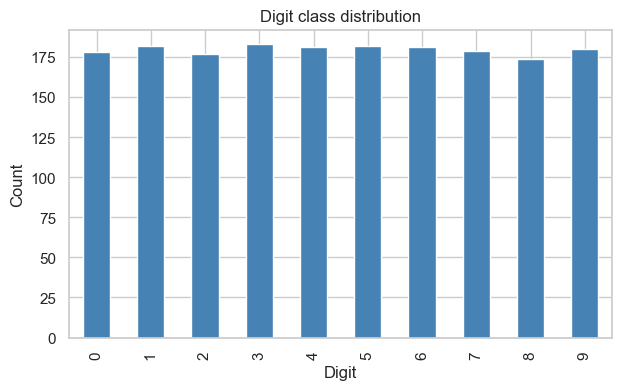

In [23]:
# Class balance
plt.figure(figsize=(7, 4))
pd.Series(y).value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.title("Digit class distribution")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()


**Observation:** The 10 digit classes are close to evenly distributed (roughly 174-183 samples each), so accuracy is a fair metric here without needing to worry about class imbalance.

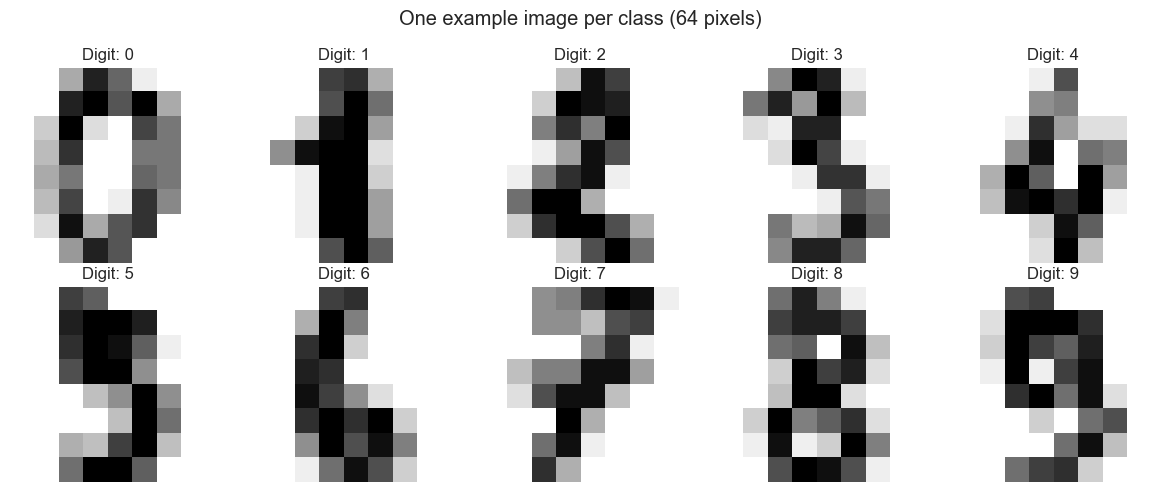

In [24]:
# What the raw data actually looks like: each row is a flattened 8x8 image
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    sample_image = X[y == digit][0].reshape(8, 8)
    ax.imshow(sample_image, cmap="gray_r")
    ax.set_title(f"Digit: {digit}")
    ax.axis("off") 
plt.suptitle("One example image per class (64 pixels)")
plt.tight_layout() 
plt.savefig('Sample_digits_grid.png')
plt.show()  

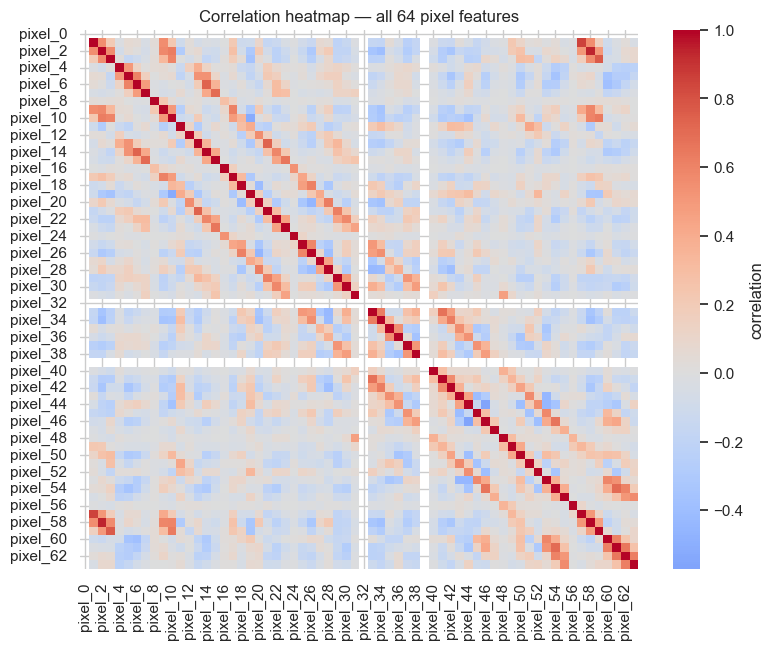

In [25]:
# Correlation between pixel features - lots of redundancy, since neighboring pixels
# tend to be dark/light together, and corner pixels are almost always 0 across all digits
corr = df.drop(columns="label").corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap="coolwarm", center=0, cbar_kws={"label": "correlation"})
plt.title("Correlation heatmap — all 64 pixel features")
plt.savefig('../images/Pixel_correlation_heatmap.png')
plt.show()


**Observation:** Many pixels are correlated with their neighbors (adjacent pixels tend to light up together as part of a stroke), and the corner pixels barely vary at all across samples (they're almost always background/0). This redundancy is exactly what PCA compresses away — this dataset is a clean, visual example of the same idea as the correlation heatmap we saw in the HAR project, just easier to see because we can literally look at the images.

## 2. Baseline Model 

Train/test split first (80/20, stratified by digit so all classes stay balanced in both sets), then a Logistic Regression trained directly on all 64 standardized pixel features. This is the benchmark we compare the PCA-reduced model against in Module 4.

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state= RANDOM_STATE)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (1437, 64)
X_test : (360, 64)


In [27]:
# Standardize using the train set's mean/std only, then apply the same transform to test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
baseline_model = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)

start = time.time()
baseline_model.fit(X_train_scaled, y_train)
baseline_train_time = time.time() - start

start = time.time()
y_pred_baseline = baseline_model.predict(X_test_scaled)
baseline_predict_time = time.time() - start

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print(f"Baseline (64 raw pixel features)")
print(f"  Accuracy      : {baseline_accuracy:.4f}")
print(f"  Training time : {baseline_train_time:.3f} sec")
print(f"  Predict time  : {baseline_predict_time:.4f} sec")


Baseline (64 raw pixel features)
  Accuracy      : 0.9722
  Training time : 0.103 sec
  Predict time  : 0.0006 sec


In [29]:
print(classification_report(y_test,y_pred_baseline))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      0.97      0.97        34
           4       1.00      0.98      0.99        46
           5       0.94      0.94      0.94        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.93      0.95      0.94        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



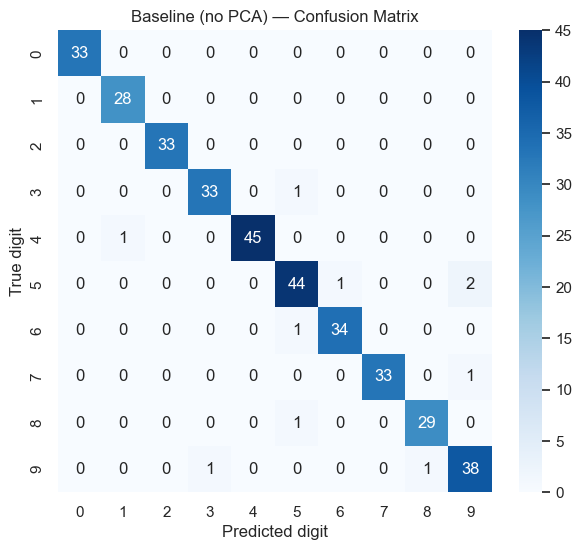

In [30]:
cm = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.title("Baseline (no PCA) — Confusion Matrix")
plt.ylabel("True digit")
plt.xlabel("Predicted digit")
plt.show()


**Observation:** Accuracy is already very high on raw pixels — Logistic Regression handles this small, clean dataset well. The few errors that do happen tend to be between visually similar digit pairs (e.g., 8 and 1, or 9 and 5), which we'll see again in the PCA-reduced model's confusion matrix.

## 3. Applying PCA

Fit PCA on the standardized training data, inspect the explained variance, and choose k using the cumulative-variance-threshold method (retain 95% of the variance), same approach as the theory notes and the HAR project.

In [31]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

explained_var_ratio = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var_ratio)

print("Variance explained by PC1:", round(explained_var_ratio[0] * 100, 2), "%")
print("Variance explained by PC2:", round(explained_var_ratio[1] * 100, 2), "%")
print("Cumulative variance, top 10 components:", round(cumulative_var[9] * 100, 2), "%")
print("Cumulative variance, top 25 components:", round(cumulative_var[24] * 100, 2), "%")


Variance explained by PC1: 12.04 %
Variance explained by PC2: 9.73 %
Cumulative variance, top 10 components: 59.23 %
Cumulative variance, top 25 components: 85.38 %


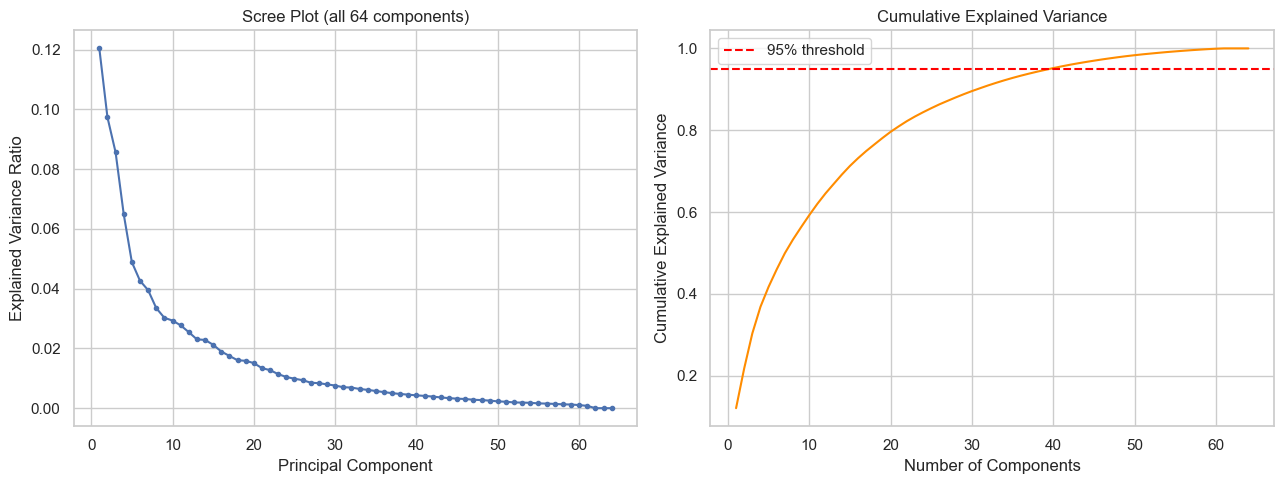

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(range(1, len(explained_var_ratio) + 1), explained_var_ratio, marker="o", markersize=3)
axes[0].set_title("Scree Plot (all 64 components)")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")

axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var, color="darkorange")
axes[1].axhline(y=0.95, color="red", linestyle="--", label="95% threshold")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/Scree plot_and_cumulative_explained_variance.png',dpi=100)
plt.show()

In [33]:
target_variance = 0.95
k = np.argmax(cumulative_var >= target_variance) + 1

print(f"Number of components needed to explain {target_variance*100:.0f}% variance: {k}")
print(f"Original dimensionality : {X_train_scaled.shape[1]}")
print(f"Reduced dimensionality  : {k}")
print(f"Compression : {X_train_scaled.shape[1]} -> {k} features "f"({(1 - k / X_train_scaled.shape[1]) * 100:.1f}% reduction)")


Number of components needed to explain 95% variance: 40
Original dimensionality : 64
Reduced dimensionality  : 40
Compression : 64 -> 40 features (37.5% reduction)


In [34]:
pca = PCA(n_components=k, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("X_train_pca shape:", X_train_pca.shape)
print("X_test_pca shape :", X_test_pca.shape)
print(f"Variance retained with k={k}: {pca.explained_variance_ratio_.sum()*100:.2f}%")

X_train_pca shape: (1437, 40)
X_test_pca shape : (360, 40)
Variance retained with k=40: 95.18%


## 4. Model on PCA-reduced Data + Visualization

Same classifier, same hyperparameters, same train/test split — only the input changes: PCA-reduced features instead of the raw 64 pixels.

In [35]:
pca_model = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)

start = time.time()
pca_model.fit(X_train_pca, y_train)
pca_train_time = time.time() - start

start = time.time()
y_pred_pca = pca_model.predict(X_test_pca)
pca_predict_time = time.time() - start

pca_accuracy = accuracy_score(y_test, y_pred_pca)

print(f"PCA-reduced ({k} components)")
print(f"  Accuracy      : {pca_accuracy:.4f}")
print(f"  Training time : {pca_train_time:.3f} sec")
print(f"  Predict time  : {pca_predict_time:.4f} sec")


PCA-reduced (40 components)
  Accuracy      : 0.9611
  Training time : 0.141 sec
  Predict time  : 0.0010 sec


In [36]:
print(classification_report(y_test, y_pred_pca))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.93      0.96      0.95        28
           2       0.97      0.97      0.97        33
           3       0.97      0.97      0.97        34
           4       0.98      1.00      0.99        46
           5       0.94      0.94      0.94        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.90      0.90      0.90        30
           9       0.95      0.93      0.94        40

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



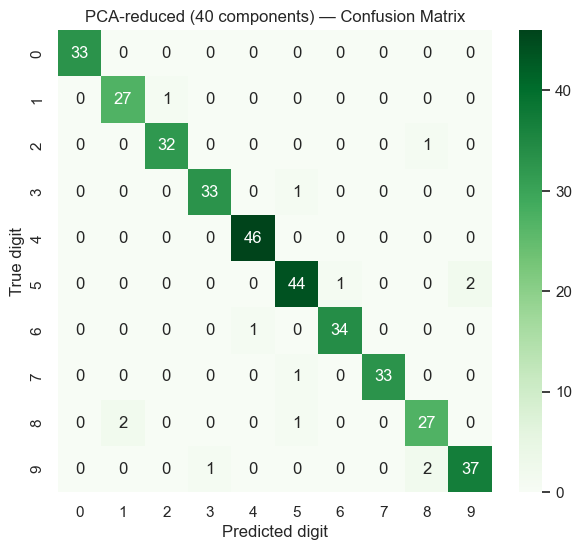

In [37]:
cm_pca = confusion_matrix(y_test, y_pred_pca)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_pca, annot=True, fmt="d", cmap="Greens", xticklabels=range(10), yticklabels=range(10))
plt.title(f"PCA-reduced ({k} components) — Confusion Matrix")
plt.ylabel("True digit")
plt.xlabel("Predicted digit")
plt.show() 

### 2D visualization
A separate 2-component PCA (fit only for plotting, not used for the model above) shows how well just PC1 vs PC2 already separate the 10 digit classes.

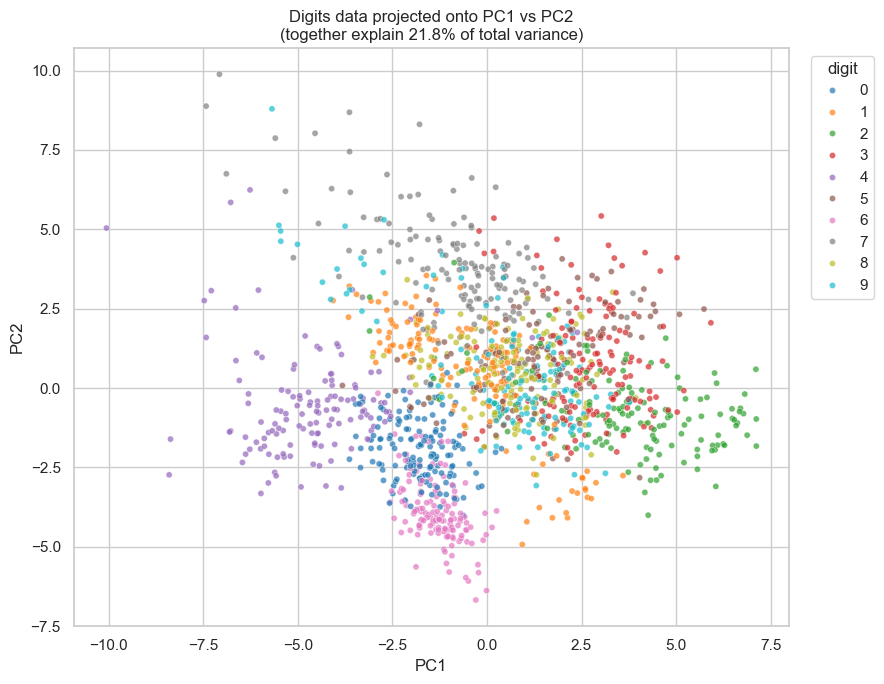

In [38]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca_2d.fit_transform(X_train_scaled)
  
plot_df = pd.DataFrame(X_train_2d, columns=["PC1", "PC2"])
plot_df["digit"] = y_train

plt.figure(figsize=(9, 7))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="digit", palette="tab10", s=20, alpha=0.7)
plt.title(f"Digits data projected onto PC1 vs PC2\n"
          f"(together explain {pca_2d.explained_variance_ratio_.sum()*100:.1f}% of total variance)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="digit")
plt.tight_layout() 
plt.savefig('../images/2D_PCA_scatter.png')
plt.show()


**Observation:** Even with only 2 of 64 dimensions, several digits (like 0 and 4) already form fairly distinct clusters, while others overlap more — those overlapping ones are exactly where we'd expect more confusion in a low-dimension model, and they roughly match the harder pairs in the confusion matrices above.

### Reconstructing digits from PCA components

Since this is image data, we can directly *see* what PCA's lossy reconstruction (Module 4 theory) looks like — reconstructing the original 8x8 images from just a handful of components, then comparing to the originals.

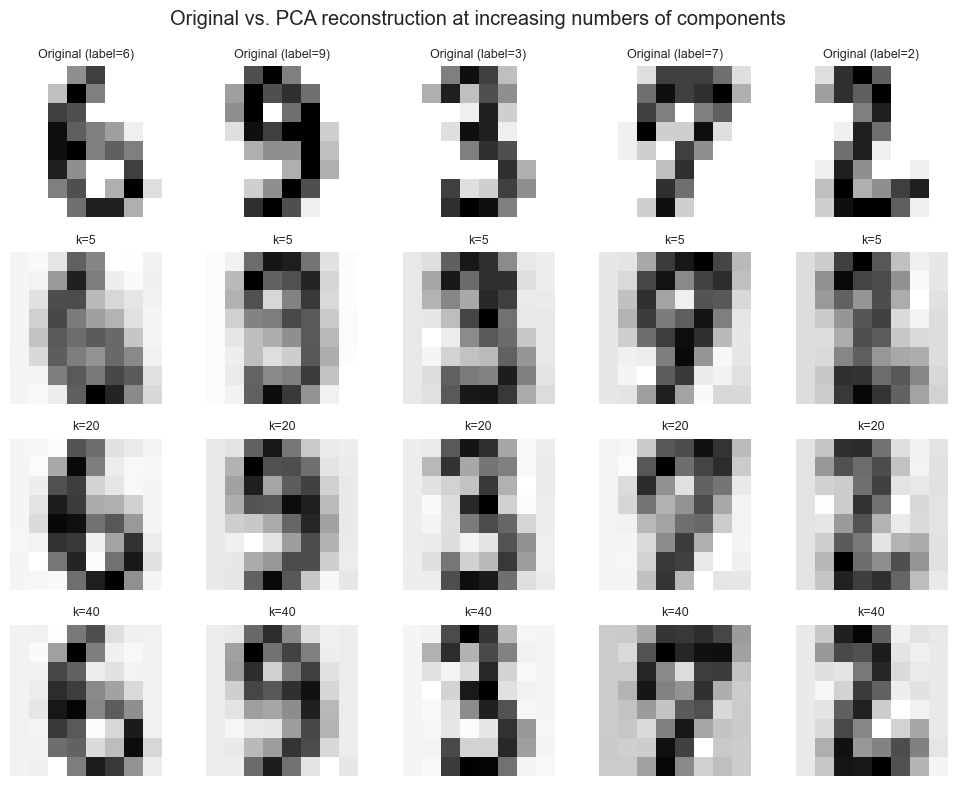

In [39]:
def reconstruct_with_k_components(X_scaled_sample, k_components, scaler, X_train_scaled_ref, random_state=RANDOM_STATE):
    pca_k = PCA(n_components=k_components, random_state=random_state)
    pca_k.fit(X_train_scaled_ref)
    transformed = pca_k.transform(X_scaled_sample)
    reconstructed_scaled = pca_k.inverse_transform(transformed)
    reconstructed = scaler.inverse_transform(reconstructed_scaled)
    return reconstructed

# Pick a handful of sample test images to visualize
sample_idx = [0, 1, 2, 3, 4]
sample_scaled = X_test_scaled[sample_idx]
k_values_to_show = [5, 20, k]  # low, medium, our chosen 95%-variance k

fig, axes = plt.subplots(len(k_values_to_show) + 1, len(sample_idx), figsize=(2 * len(sample_idx), 2 * (len(k_values_to_show) + 1)))

# Row 0: originals
for col, idx in enumerate(sample_idx):
    axes[0, col].imshow(X_test[idx].reshape(8, 8), cmap="gray_r")
    axes[0, col].set_title(f"Original (label={y_test[idx]})", fontsize=9)
    axes[0, col].axis("off")

# Remaining rows: reconstructions at each k
for row, kk in enumerate(k_values_to_show, start=1):
    recon = reconstruct_with_k_components(sample_scaled, kk, scaler, X_train_scaled)
    for col in range(len(sample_idx)):
        axes[row, col].imshow(recon[col].reshape(8, 8), cmap="gray_r")
        axes[row, col].set_title(f"k={kk}", fontsize=9)
        axes[row, col].axis("off")

plt.suptitle("Original vs. PCA reconstruction at increasing numbers of components")
plt.tight_layout()
plt.savefig('Original_vs_reconstructed_digits.png')
plt.show()


**Observation:** With very few components (k=5) the reconstructions are blurry — recognizable in shape but missing detail. By k=20 they're already close to the originals. At our chosen k (95% variance retained), the reconstructions are visually almost indistinguishable from the originals. This is the reconstruction concept from Module 4 theory made visible: **more components = closer reconstruction = less information discarded**, and the whole point of picking k via the 95% threshold is finding the point where you've discarded the least-informative variance (mostly fine detail/noise) while keeping everything that actually defines the digit's shape.

## 5. Insights & Comparison

In [40]:
comparison = pd.DataFrame({
    "Metric": ["Number of features", "Accuracy", "Training time (sec)", "Predict time (sec)"],
    "Baseline (no PCA)": [X_train_scaled.shape[1], round(baseline_accuracy, 4),
                           round(baseline_train_time, 3), round(baseline_predict_time, 4)],
    f"PCA-reduced (k={k})": [k, round(pca_accuracy, 4),
                              round(pca_train_time, 3), round(pca_predict_time, 4)]})
comparison


,Metric,Baseline (no PCA),PCA-reduced (k=40)
0,Number of features,64.0000,40.0000
1,Accuracy,0.9722,0.9611
2,Training time (sec),0.1030,0.1410
3,Predict time (sec),0.0006,0.0010


### Summary

- PCA compressed the feature space from **64 pixels down to `k` components** (see the exact count printed in Module 3 — still a meaningful reduction, though nowhere near as dramatic as the 561→102 compression in the HAR project, since this dataset already starts with far fewer, denser features).
- Accuracy on the PCA-reduced features stayed **very close to the raw-pixel baseline** — PCA is not throwing away information the classifier actually needed, just the low-variance/noisy detail.
- Training time is small either way on a dataset this size (1,797 samples), but the gap still shows the same direction as HAR: fewer input dimensions → less for the model to fit.
- The reconstruction visualization is the most direct, intuitive proof of what PCA is doing here — you can literally watch a digit sharpen as k increases, whereas with HAR's sensor features there was nothing to visually "look at" in the same way.
